                                                Review
0                                 또 이어지나요! 잼있게 보았어요~^^
1               사운드가 웅장하고 아이맥스로도 보고싶어지네요.. 파트3도 기다려집니다
2                                         압도적인 체험 입니다!
3                       방식과 템포의 유지속에 할애한 시간만큼의 납득에는 의문
4                              IMAX로 보는 듄 : 파트2 볼만했어요.
..                                                 ...
595  2회차인데 확실히 큰화면과 사운드 좋은걸로 보니 몰입감이 더 좋네여 이양이면 아이맥...
596                      영화관에서 꼭 봐야하는 영화네요! 재밌게 잘 봤어요.
597                                   재밌어요~ 1을 안봤지만 ㅎㅎ
598                                    꼭 반드시 IMAX로!!!!
599                                     1편봐도 이해 어려울수도?

[600 rows x 1 columns] 

0                                                    [잼]
1                            [사운드, 아이맥스, 지네, 파트, 파트3, 3]
2                                     [압도, 압도적인, 적인, 체험]
3         [방식, 템포, 유지, 유지속, 속, 할애, 시간, 시간만큼, 만큼, 납득, 의문]
4                                        [듄, 파트, 파트2, 2]
                             

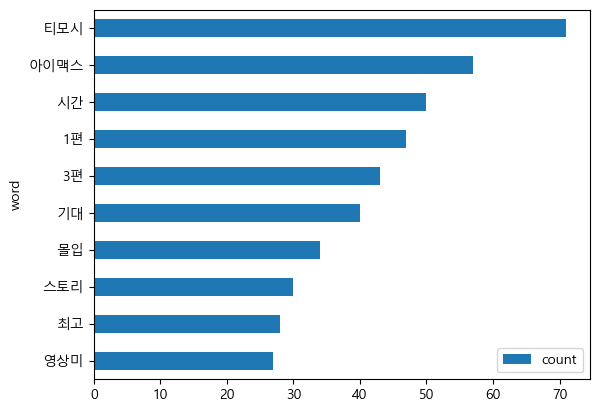

{'티모시': 71, '아이맥스': 57, '시간': 50, '1편': 47, '3편': 43, '기대': 40, '몰입': 34, '스토리': 30, '최고': 28, '영상미': 27, '스케일': 23, '관람': 20, '사막': 19, '연기': 18, '다음': 18, '가입': 18, '사운드': 17, '이해': 16, '배우': 16, '3시간': 15, '몰입감': 15, '느낌': 15, '내용': 15, '듄1': 15, '모래': 15, '2편': 14, '리산': 14, '시작': 14, '파트2': 13, '압도': 13, '세계관': 13, '전개': 13, '연출': 13, '음향': 12, '영상': 12, '감독': 12, '재미': 12, '화면': 11, '장엄': 11, '타임': 11, '듄3': 11, '파트1': 11, '추천': 10, '음악': 10, '이유': 10, '극장': 10, '전쟁': 9, '하나': 9, '사람': 9, '이상': 9, '이야기': 9, '원작': 9, '장면': 9, '듄2': 8, '반지': 8, '서사시': 8, '진짜': 8, '볼만': 8, '만족': 8, '완벽': 8, '배경': 8, '상영': 8, '액션': 8, '제왕': 8, '스크린': 8, '거대': 8, '중간': 7, '주인공': 7, '보세': 7, '전편': 7, '러닝': 7, '러닝타임': 7, '자체': 7, '압도적': 7, '생각': 7, '다음편이': 7, '정도': 6, '처음': 6, '사랑': 6, '일반': 6, '소설': 6, '종교': 6, '만큼': 6, '적인': 6, '보고': 6, '예매': 6, '압도적인': 6, '상영시간': 6, '시리즈': 6, '가능': 5, '집중': 5, '벌레': 5, '우리': 5, '우슬': 5, '오랜만': 5, '3부': 5, '마음': 5, '이것': 5, '전투': 5, '완전': 5, '흥미': 5, '순삭': 5, '볼거리': 5

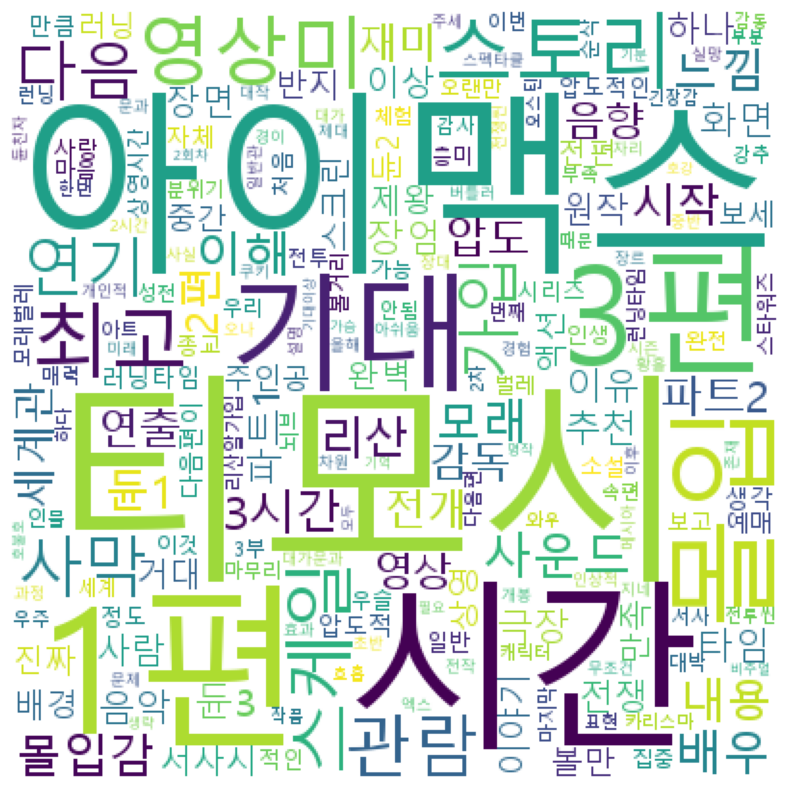

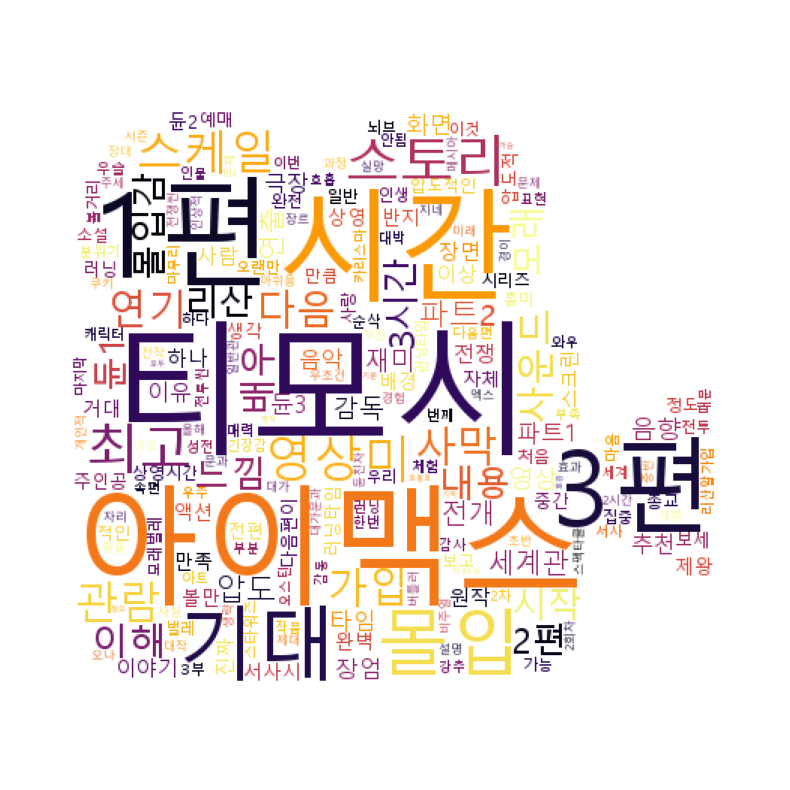

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import konlpy

df = pd.read_csv("../data/movie1_review.csv")
print(df, '\n')

kkma = konlpy.tag.Kkma()

nouns = df['Review'].apply(kkma.nouns)
print(nouns, '\n')

nouns = nouns.explode()
print(nouns, '\n')

nouns[nouns == '모시'] = '티모시'
nouns[nouns == 'IMAX'] = '아이맥스'
nouns[nouns == '파트3'] = '3편'

df_word = pd.DataFrame({'word' : nouns})
df_word['count'] = df_word['word'].str.len()
df_word = df_word.query('count >= 2')
print(df_word, '\n')

df_word = df_word.groupby('word', as_index = False)
df_word = df_word.count().sort_values('count', ascending = False)
print(df_word, '\n')

del_idx = df_word.loc[df_word.word.isin(['영화', '편이', '영화관', '파트'])].index
df_word = df_word.drop(index = del_idx)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_top10 = df_word.iloc[:10, :].sort_values('count', ascending = True)
df_top10.plot.barh(x = 'word', y = 'count')
plt.show()

dic_word = df_word.set_index('word').to_dict()['count']
print(dic_word, '\n')

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/malgun.ttf',
               width = 400,
               height = 400,
               background_color = 'white')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()

import PIL
import numpy as np

icon = PIL.Image.open('C:/Users/user/Desktop/BigData-Study/실습코드/data/movie.png').convert("RGBA")
img = PIL.Image.new(mode = "RGBA", size = icon.size, color = (255, 255, 255))
img.paste(icon, icon)
img = np.array(img)

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/malgun.ttf',
               width = 400,
               height = 400,
               background_color = 'white',
               mask = img,
               colormap = 'inferno')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()

                                                Review
0                             "유엔과 한국: 함께 이루는 인류의 꿈"\n
1                                                   \n
2    존경하는 국민 여러분, 존경하는 강창희 국회의장님과 국회의원 여러분, 그리고 주한 ...
3                                                   \n
4    한국과 유엔의 길고 특별한 인연을 생각할 때, 저의 두 번째 임기를 시작하면서 대한...
..                                                 ...
152  저는 유엔 사무총장에 취임한 첫 날부터 솔선수범하며 일신 우일신하는 자세로 지내왔습...
153                                                 \n
154   대한민국의 앞날에 무궁한 영광이 깃들고, 국민 여러분께 만복이 충만하시기를 빕니다.\n
155                                                 \n
156                                     경청해 주셔서 감사합니다.

[157 rows x 1 columns] 

0                                        [유엔, 한국, 인류, 꿈]
1                                                     []
2      [존경, 국민, 여러분, 강, 강창희, 창희, 국회, 장님, 국회의원, 주한, 외교...
3                                                     []
4      [한국, 유엔, 특별, 인연, 생각, 때, 저, 번째, 임기, 시작, 대한, 대한민...
                             

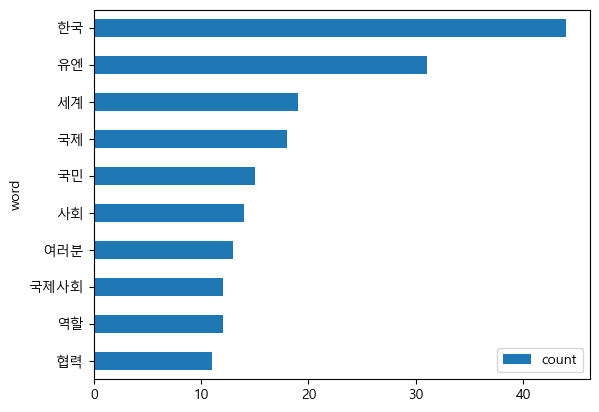

{'한국': 44, '유엔': 31, '세계': 19, '국제': 18, '국민': 15, '사회': 14, '여러분': 13, '역할': 12, '국제사회': 12, '협력': 11, '개발': 10, '노력': 10, '평화': 10, '기대': 9, '세계적': 9, '유엔사무총장': 9, '경험': 8, '희망': 8, '미래': 8, '내외귀빈': 8, '지도자': 8, '존경': 8, '문제': 8, '기여': 8, '귀빈': 8, '내외': 8, '필요': 7, '주의': 7, '목표': 7, '증진': 7, '인권': 7, '적인': 6, '특별': 6, '경제': 6, '도움': 6, '국회의원': 6, '민국': 6, '사업': 6, '지속': 5, '자리': 5, '국회': 5, '달성': 5, '지원': 5, '성공': 5, '평가': 5, '취임': 5, '가능': 5, '민주주의': 5, '이행': 5, '여성': 5, '인류': 5, '중요': 5, '변화': 5, '민주': 5, '보편적': 5, '활동': 4, '최근': 4, '추구': 4, '한반도': 4, '감사': 4, '대처': 4, '기회': 4, '2015': 4, '2015년': 4, '회의': 4, '확대': 4, '확신': 4, '시기': 4, '세대': 4, '실현': 4, '개선': 4, '계속': 4, '정부': 4, '결과': 4, '유지': 4, '가지': 4, '주민': 4, '강화': 4, '주도': 4, '적극적': 4, '안전': 4, '이상': 4, '이야기': 4, '북한': 4, '대외': 4, '모든': 4, '방문': 4, '사례': 4, '분야': 4, '분쟁': 4, '대화': 4, '최선': 3, '촉구': 3, '추진': 3, '한국정부': 3, '한국인': 3, '처음': 3, '감축': 3, '총장': 3, '정신': 3, '제고': 3, '진정': 3, '지금': 3, '지역': 3, '주시기': 3, '가치': 3, '개발원

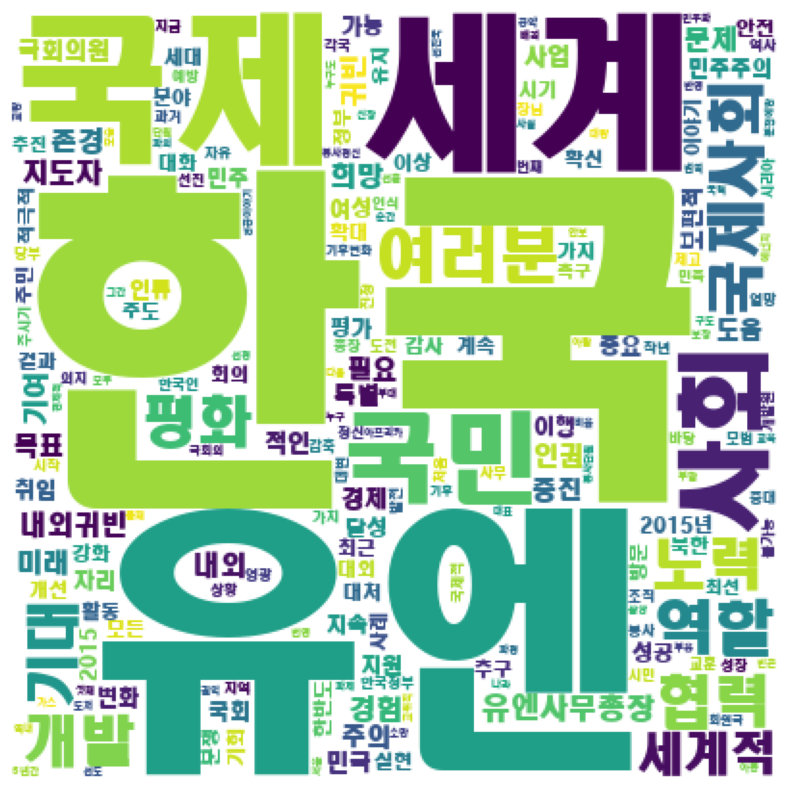

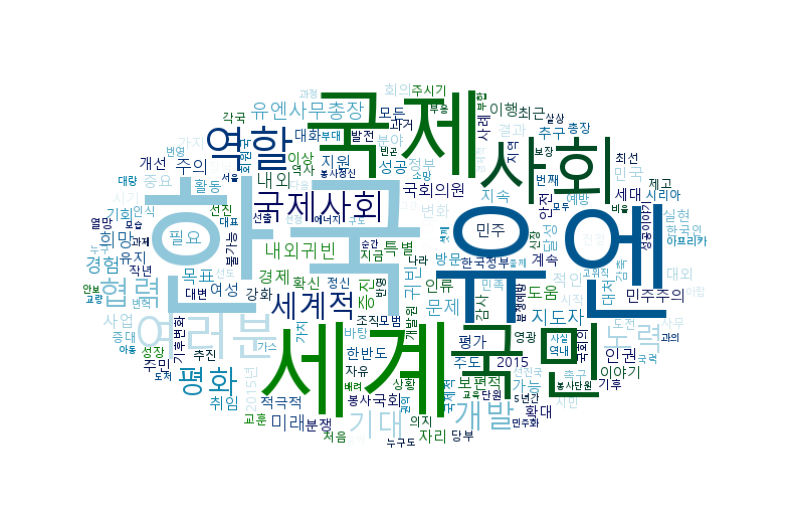

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import konlpy

with open("../data/반기문_국회_연설문.txt", 'r', encoding='utf-8') as f:
    lines = f.readlines()

# 리스트를 데이터프레임으로 변환
df = pd.DataFrame(lines, columns=['Review'])
print(df, '\n')

kkma = konlpy.tag.Kkma()

nouns = df['Review'].apply(kkma.nouns)
print(nouns, '\n')

nouns = nouns.explode()
print(nouns, '\n')

nouns[nouns == '대한민국'] = '한국'
nouns[nouns == 'UN'] = '유엔'
nouns[nouns == '사무총장'] = '유엔사무총장'

df_word = pd.DataFrame({'word' : nouns})
df_word['count'] = df_word['word'].str.len()
df_word = df_word.query('count >= 2')
print(df_word, '\n')

df_word = df_word.groupby('word', as_index = False)
df_word = df_word.count().sort_values('count', ascending = False)
print(df_word, '\n')

del_idx = df_word.loc[df_word.word.isin(['오늘', '이번', '우리', '사람', '국가', '생각', '말씀', '하나', '부분', '대한'])].index
df_word = df_word.drop(index = del_idx)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_top10 = df_word.iloc[:10, :].sort_values('count', ascending = True)
df_top10.plot.barh(x = 'word', y = 'count')
plt.show()

dic_word = df_word.set_index('word').to_dict()['count']
print(dic_word, '\n')

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/HMKMRHD.TTF',
               width = 400,
               height = 400,
               background_color = 'white')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()

import PIL
import numpy as np

icon = PIL.Image.open('C:/Users/user/Desktop/BigData-Study/실습코드/data/oval.png').convert("RGBA")
img = PIL.Image.new(mode = "RGBA", size = icon.size, color = (255, 255, 255))
img.paste(icon, icon)
img = np.array(img)

wc = WordCloud(random_state = 123,
               font_path = 'C:/Windows/Fonts/malgun.ttf',
               width = 400,
               height = 400,
               background_color = 'white',
               mask = img,
               colormap = 'ocean')

img_wordcloud = wc.generate_from_frequencies(dic_word)

plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(img_wordcloud)
plt.show()